In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
rainfall = pd.read_csv("rainfall.csv")
population = pd.read_csv("population.csv",header=None)
groundwater = pd.read_csv("groundwater.csv")

In [4]:
print(rainfall.head())
print(population.head())
print(groundwater.head())

                 SUBDIVISION  YEAR   JAN    FEB   MAR    APR    MAY    JUN  \
0  ANDAMAN & NICOBAR ISLANDS  1901  49.2   87.1  29.2    2.3  528.8  517.5   
1  ANDAMAN & NICOBAR ISLANDS  1902   0.0  159.8  12.2    0.0  446.1  537.1   
2  ANDAMAN & NICOBAR ISLANDS  1903  12.7  144.0   0.0    1.0  235.1  479.9   
3  ANDAMAN & NICOBAR ISLANDS  1904   9.4   14.7   0.0  202.4  304.5  495.1   
4  ANDAMAN & NICOBAR ISLANDS  1905   1.3    0.0   3.3   26.9  279.5  628.7   

     JUL    AUG    SEP    OCT    NOV    DEC  ANNUAL  Jan-Feb  Mar-May  \
0  365.1  481.1  332.6  388.5  558.2   33.6  3373.2    136.3    560.3   
1  228.9  753.7  666.2  197.2  359.0  160.5  3520.7    159.8    458.3   
2  728.4  326.7  339.0  181.2  284.4  225.0  2957.4    156.7    236.1   
3  502.0  160.1  820.4  222.2  308.7   40.1  3079.6     24.1    506.9   
4  368.7  330.5  297.0  260.7   25.4  344.7  2566.7      1.3    309.7   

   Jun-Sep  Oct-Dec  
0   1696.3    980.3  
1   2185.9    716.7  
2   1874.0    690.6  
3   

In [5]:
rainfall.columns = rainfall.columns.str.strip()

rainfall.rename(columns={
    'SUBDIVISION': 'State',
    'YEAR': 'Year',
    'ANNUAL': 'Rainfall'
}, inplace=True)
rainfall = rainfall[['Year', 'State', 'Rainfall']]
rainfall = rainfall[rainfall['Year'] >= 1950]
rainfall = rainfall[
    rainfall['State'] == 'SOUTH INTERIOR KARNATAKA'
]


print(rainfall.head())
print(rainfall.shape)

      Year                     State  Rainfall
3821  1950  SOUTH INTERIOR KARNATAKA     956.5
3822  1951  SOUTH INTERIOR KARNATAKA     925.3
3823  1952  SOUTH INTERIOR KARNATAKA     871.8
3824  1953  SOUTH INTERIOR KARNATAKA    1255.9
3825  1954  SOUTH INTERIOR KARNATAKA    1031.1
(66, 3)


In [6]:
population.columns = ['Year', 'Population']
population['Year'] = pd.to_numeric(
    population['Year'],
    errors='coerce'
)
population['Population'] = pd.to_numeric(
    population['Population'],
    errors='coerce'
)
population = population.dropna()
population['Year'] = population['Year'].astype(int)
population['Population'] = population['Population'].astype(int)
print(population.head())
print(population.shape)

   Year  Population
1  1950   357021100
2  1951   364922360
3  1952   372997188
4  1953   381227705
5  1954   389731406
(76, 2)


In [7]:
groundwater.rename(columns={
    'STATE': 'State'
}, inplace=True)
groundwater['Groundwater'] = (
    groundwater['Conductivity (µmhos/cm) Min'] +
    groundwater['Conductivity (µmhos/cm) Max']
) / 2
groundwater = groundwater[['Year', 'State', 'Groundwater']]
print(groundwater.head())
print(groundwater.shape)


   Year           State  Groundwater
0  2012  ANDHRA PRADESH        210.5
1  2012  ANDHRA PRADESH        892.0
2  2012  ANDHRA PRADESH       1631.0
3  2012  ANDHRA PRADESH       1544.0
4  2012  ANDHRA PRADESH       1514.5
(395, 3)


In [8]:
rainfall = rainfall[
    rainfall['Year'] == 2012
]
population = population[
    population['Year'] == 2012]
groundwater = groundwater[
    groundwater['Year'] == 2012]
print(rainfall.shape)
print(population.shape)
print(groundwater.shape)

(1, 3)
(1, 2)
(395, 3)


In [9]:
data = rainfall.merge(
    population,
    on='Year')
data = data.merge(
    groundwater,
    on='Year'
)
if 'State_y' in data.columns:
    data = data.drop(columns=['State_y'])

if 'State_x' in data.columns:
    data.rename(columns={
        'State_x': 'State'
    }, inplace=True)
print(data.head())

print("\nDataset Shape:")
print(data.shape)

   Year                     State  Rainfall  Population  Groundwater
0  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502        210.5
1  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502        892.0
2  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1631.0
3  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1544.0
4  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1514.5

Dataset Shape:
(395, 5)


In [10]:
data = rainfall.merge(
    population,
    on='Year'
)
data = data.merge(
    groundwater,
    on='Year'
)
if 'State_y' in data.columns:
    data = data.drop(columns=['State_y'])

if 'State_x' in data.columns:
    data.rename(columns={
        'State_x': 'State'
    }, inplace=True)
print(data.head())
print("\nDataset Shape:")
print(data.shape)

   Year                     State  Rainfall  Population  Groundwater
0  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502        210.5
1  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502        892.0
2  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1631.0
3  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1544.0
4  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1514.5

Dataset Shape:
(395, 5)


             Rainfall  Population  Groundwater
Rainfall          NaN         NaN          NaN
Population        NaN         NaN          NaN
Groundwater       NaN         NaN          1.0


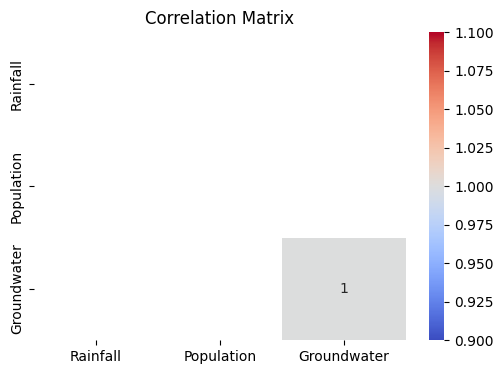

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = data[['Rainfall','Population','Groundwater']].corr()

print(correlation)

plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [12]:
gw_median = data['Groundwater'].median()

data['Risk'] = np.where(
    data['Groundwater'] > gw_median,
    1,
    0
)

print(data.head())

   Year                     State  Rainfall  Population  Groundwater  Risk
0  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502        210.5     0
1  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502        892.0     1
2  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1631.0     1
3  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1544.0     1
4  2012  SOUTH INTERIOR KARNATAKA     877.8  1278674502       1514.5     1


In [13]:
X = data[['Rainfall', 'Population', 'Groundwater']]
y = data['Risk']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [16]:
model.fit(X_train, y_train)
print(data['Risk'].value_counts())

Risk
0    198
1    197
Name: count, dtype: int64


In [17]:
pred = model.predict(X_test)

print(pred)

[1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 1 0 1 0 1
 1 0 0 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0
 0 1 0 1 0]


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[39  1]
 [ 0 39]]


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        40
           1       0.97      1.00      0.99        39

    accuracy                           0.99        79
   macro avg       0.99      0.99      0.99        79
weighted avg       0.99      0.99      0.99        79



In [20]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9873417721518988


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9873417721518988


In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9873417721518988


In [23]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, pred))

Random Forest Accuracy: 0.9873417721518988


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        40
           1       0.97      1.00      0.99        39

    accuracy                           0.99        79
   macro avg       0.99      0.99      0.99        79
weighted avg       0.99      0.99      0.99        79



In [25]:
import pickle

pickle.dump(
    model,
    open('water_crisis_model.pkl', 'wb')
)

print("Model Saved")

Model Saved
